# Section 6 — Textual sentiment over time: three corpora

Thin driver notebook: all logic lives in `src/sentiment/`.

- **Regulators** (`scrape_regulators.py`): real, free PDFs — 11 Fed Financial Stability Reports (2020-2026) and 24 BIS Quarterly Reviews. IMF GFSR and ECB's historical FSR archive weren't resolved to scriptable URLs in the time available (see `docs/excluded_sources.md`).
- **Reddit** (`scrape_reddit.py`): fully implemented, needs the user's own `REDDIT_CLIENT_ID`/`REDDIT_CLIENT_SECRET`/`REDDIT_USER_AGENT` in the environment — not present this run.
- **Transcripts** (`scrape_transcripts.py`): stubbed — no shared structure across issuer IR sites to exploit (unlike BDC SOI's XBRL fragments).
- **Alarm index** (`analysis_alarm_index.py`): scored with VADER, not the Loughran-McDonald financial lexicon the mission brief specified — LM's download link is client-rendered and wasn't resolved to a scriptable URL this pass (see that module's docstring). A real bug was caught here by inspecting the actual text being scored, not just the chart: paragraph splitting on blank lines doesn't work for this PDF-extracted text (it merges glossaries/bylines/body into multi-page blobs), which silently drove every sentiment score toward 1.0 regardless of content — fixed by scoring a small sentence-window around each CLO mention instead.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from IPython.display import Image, display

from src.sentiment import (
    scrape_regulators, scrape_reddit, scrape_transcripts,
    analysis_alarm_index, analysis_narrative_arc, analysis_retail, analysis_insider_tone,
    viz_alarm, viz_narrative, viz_retail, viz_tone,
)

/Users/zinuoshi/clo-atlas/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Scrape (raw -> interim)

In [2]:
RUN_SCRAPE = False
if RUN_SCRAPE:
    scrape_regulators.run()
    scrape_reddit.run()
    scrape_transcripts.run()

## Analysis (interim -> final)

In [3]:
alarm = analysis_alarm_index.run()
narrative = analysis_narrative_arc.run()
retail = analysis_retail.run()
insider = analysis_insider_tone.run()

no Reddit data cached (needs REDDIT_* env vars — see scrape_reddit.py); mention_volume_weekly is empty


scrape_transcripts.py is stubbed — no shared structure across issuer IR sites to exploit (unlike BDC SOI's XBRL fragments); would need one parser per company. See module docstring.


no transcript data available; tone_divergence is empty (see scrape_transcripts.py docstring)


## Viz (final -> figures/)

no Reddit data available (needs REDDIT_* env vars — see docs/excluded_sources.md); skipping viz_reddit_mentions_vs_etf_aum


no transcript tone data available (see docs/excluded_sources.md); skipping viz_tone_divergence


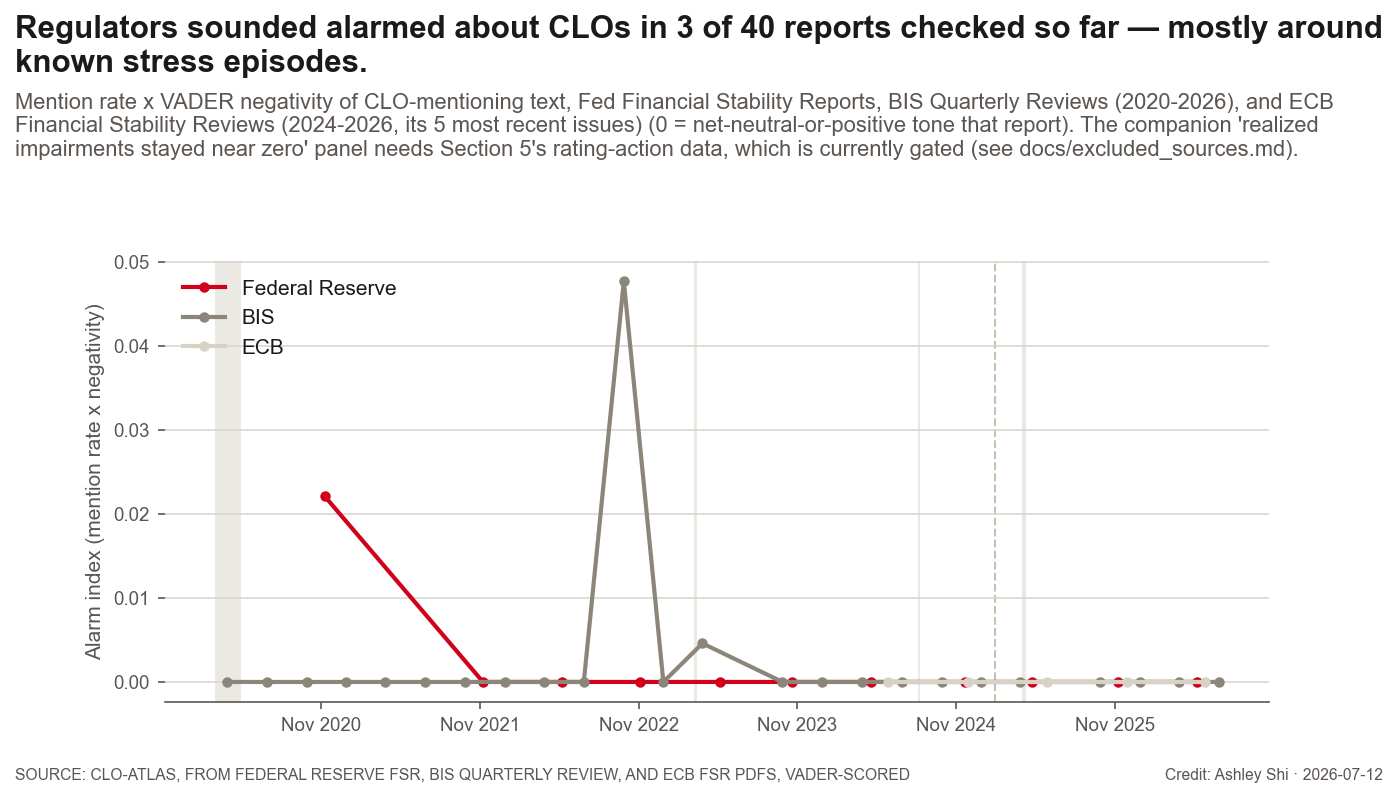

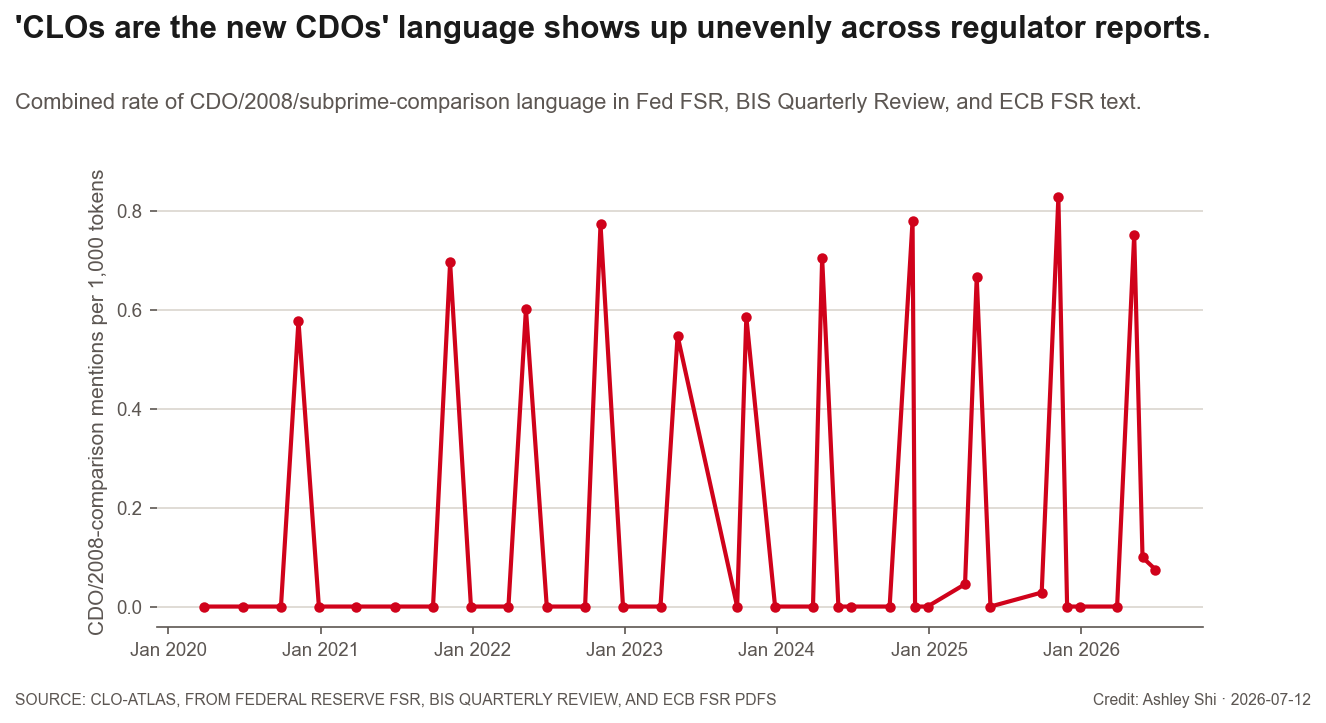

In [4]:
viz_alarm.run()
viz_narrative.run()
viz_retail.run()
viz_tone.run()

## Exhibits

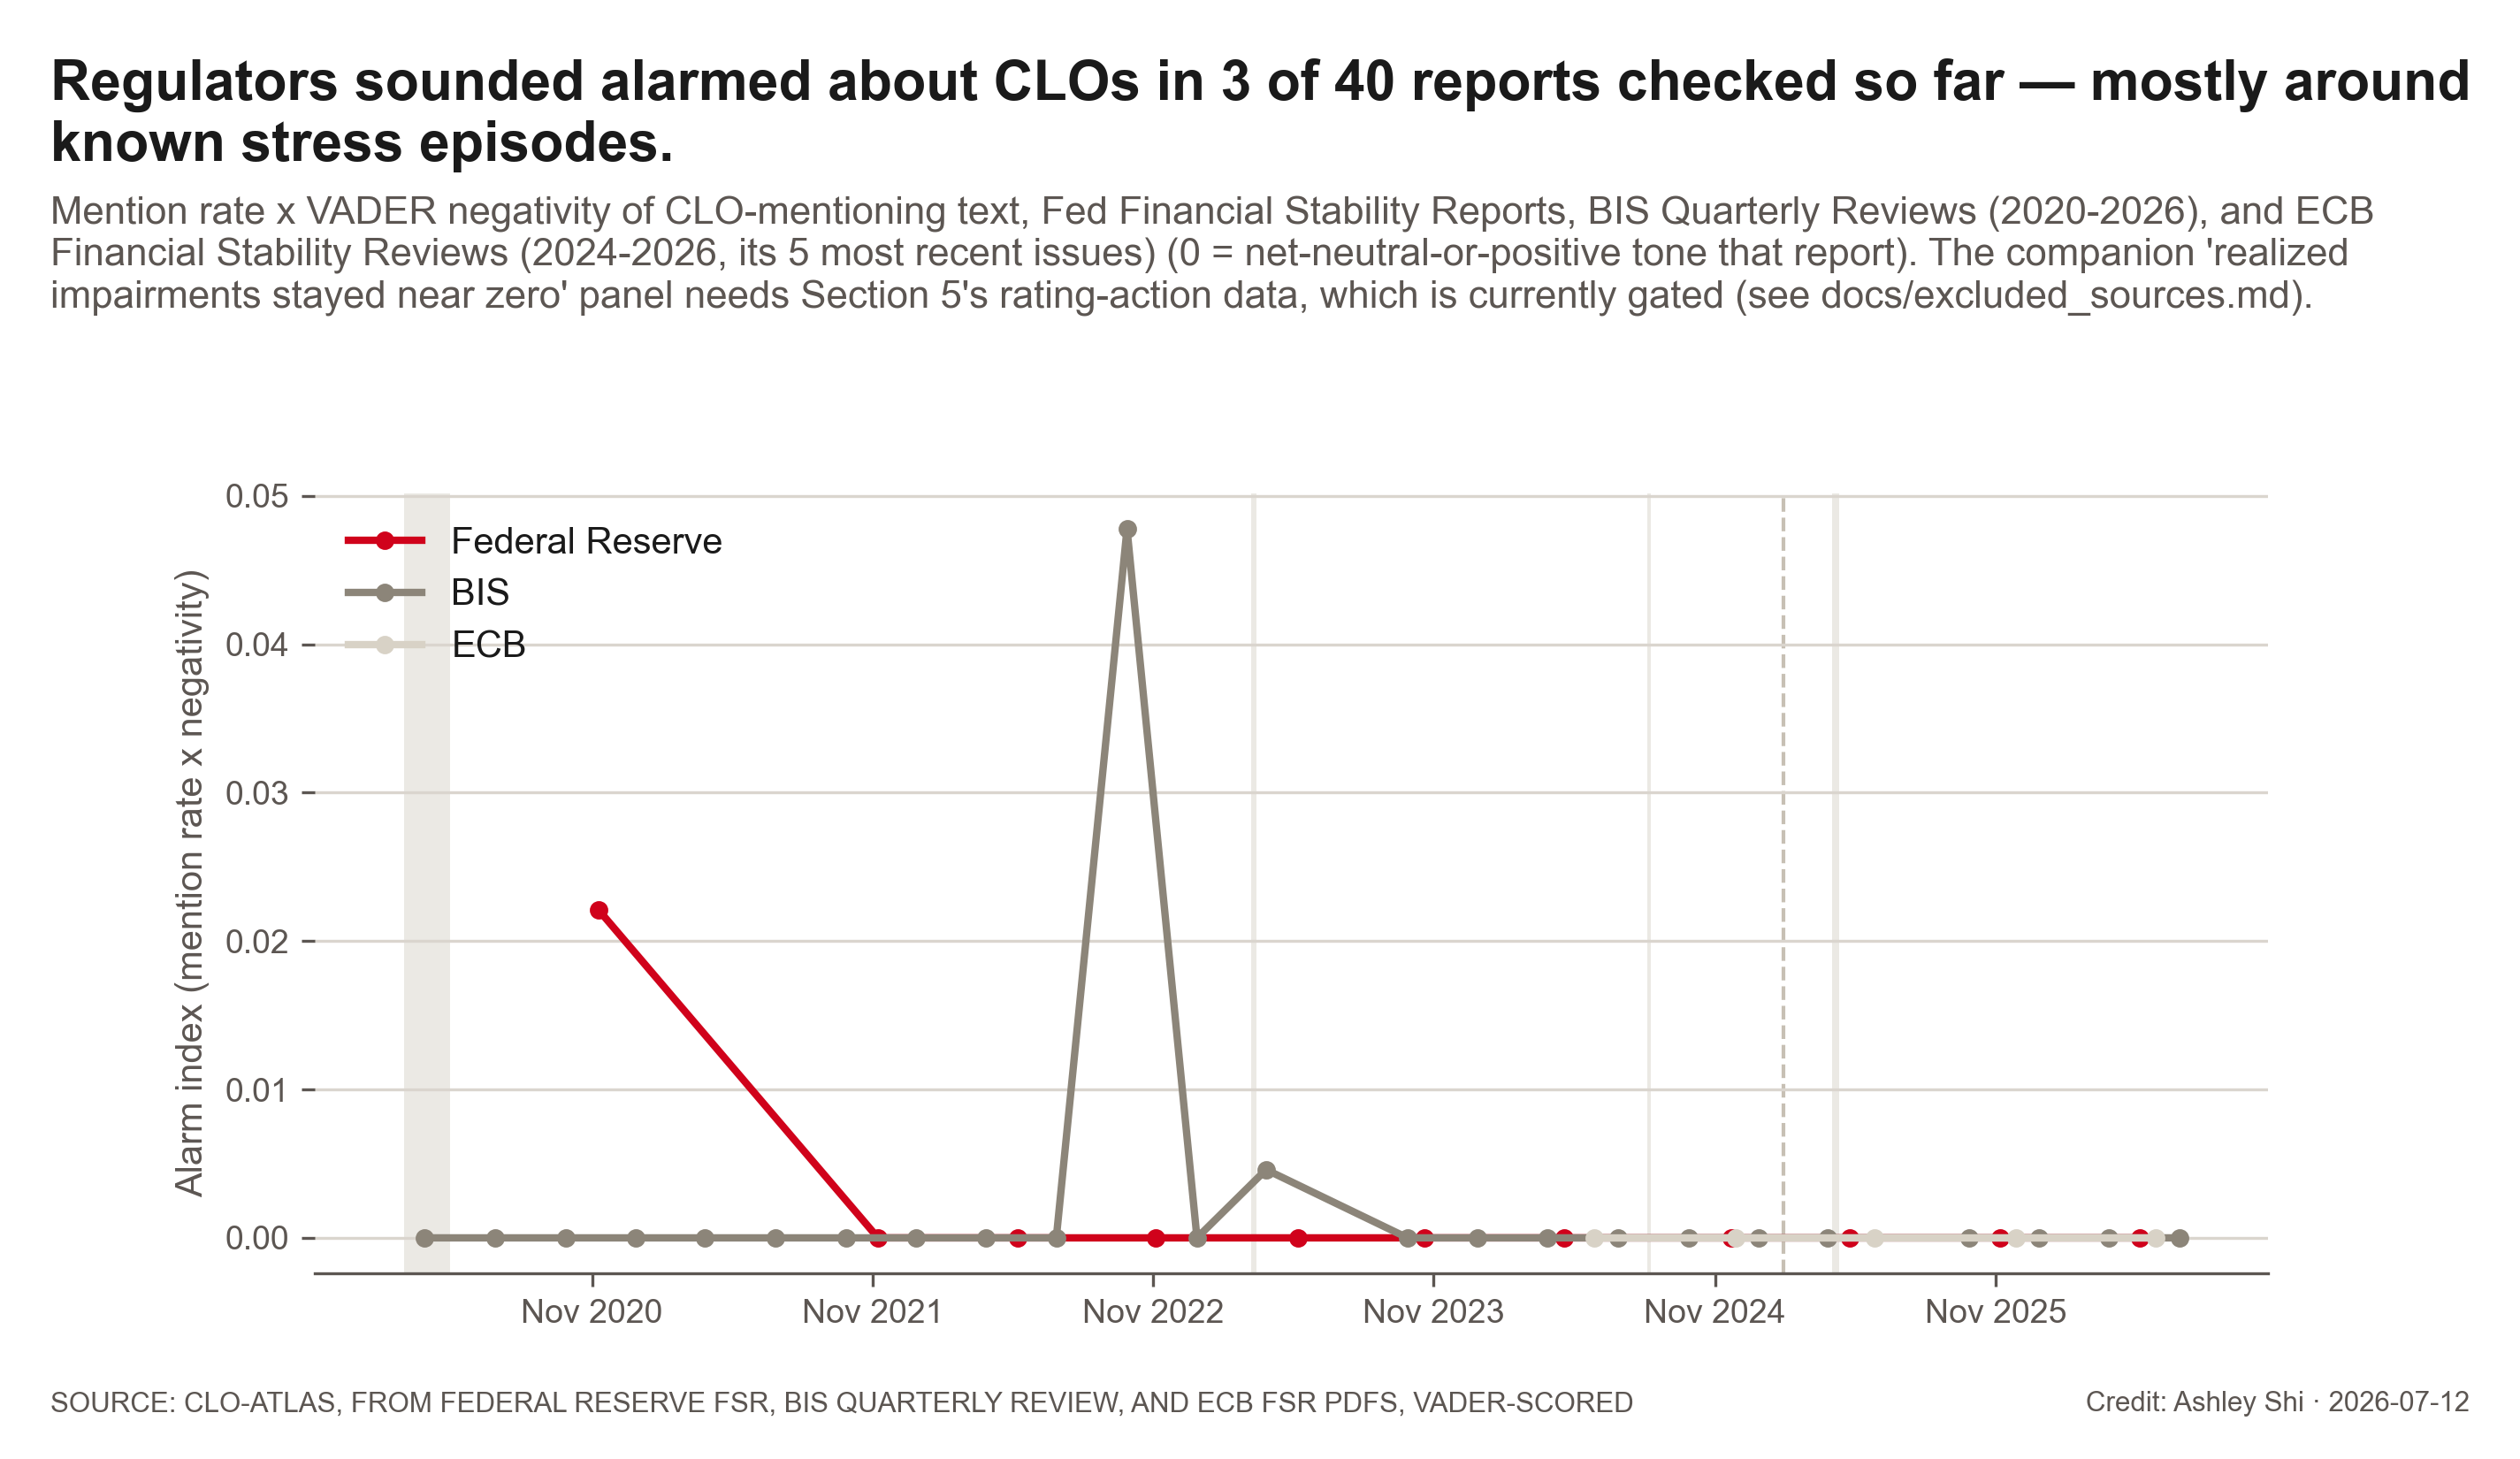

In [5]:
path = pathlib.Path("../figures") / "viz_alarm_index_over_time.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print(f"[skipped — not generated this run] viz_alarm_index_over_time")

Data: 11 Fed Financial Stability Reports, 24 BIS Quarterly Reviews, and 5 ECB Financial Stability Reviews (2020–2026) — free PDFs scraped by `scrape_regulators.py` and scored in `analysis_alarm_index.py`, which applies VADER sentiment (not the Loughran-McDonald financial lexicon originally specified — its download link wasn't resolved to a scriptable URL this pass) to a one-sentence window around every CLO mention, multiplied by mention rate per 1,000 tokens. **VERIFIED**.

The chart plots that alarm index over time, one line per institution (Federal Reserve, BIS, ECB), with event flags marking known stress episodes. **VERIFIED**: only 3 of these 40 reports score net-negative on CLO-mentioning text overall — the Federal Reserve's November 2020 report and the BIS's Q3 2022 report are the two largest spikes, with the rest reading net-neutral to mildly positive.

For a deck introducing CLOs as an asset class, this is the headline regulatory-sentiment fact: alarm is real but episodic, tracking systemic stress (COVID, the 2022 rate-hiking cycle) rather than constant skepticism about the structure itself.

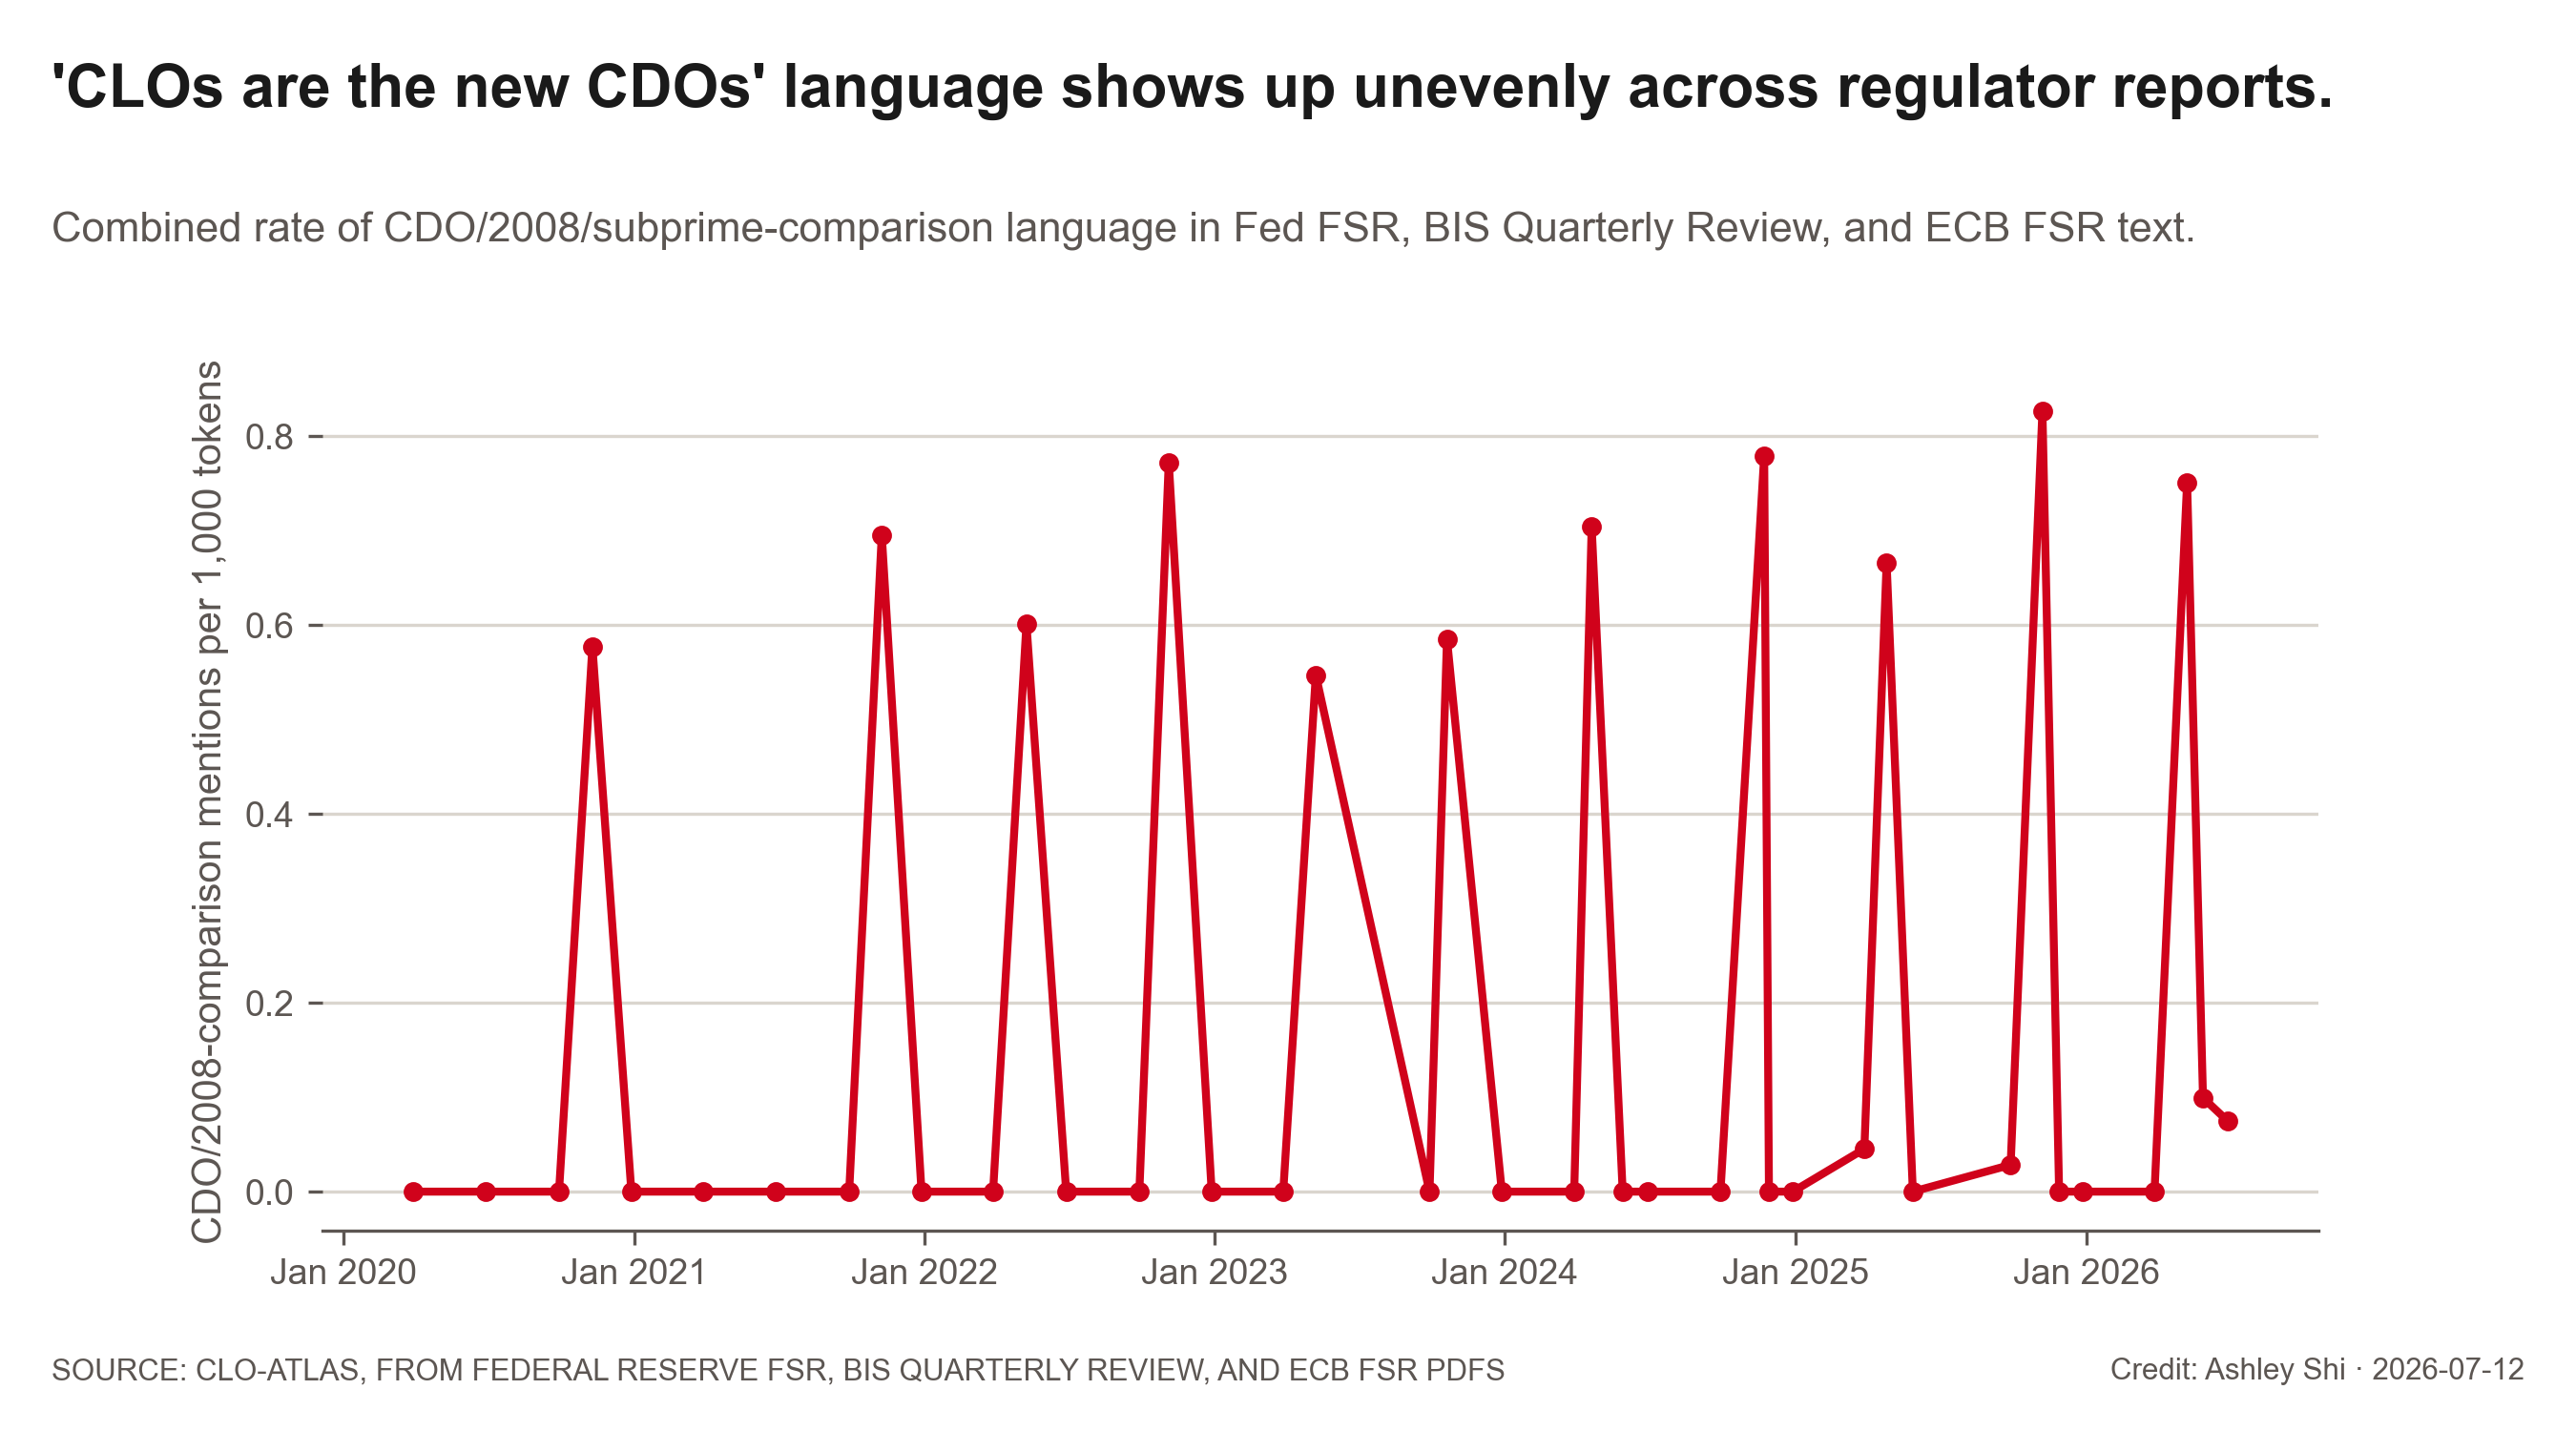

In [6]:
path = pathlib.Path("../figures") / "viz_cdo_comparison_frequency.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print(f"[skipped — not generated this run] viz_cdo_comparison_frequency")

Data: the same Fed/BIS/ECB regulator-report corpus, scored in `analysis_narrative_arc.py` for six explicit CDO/2008-comparison phrases ("like CDOs," "reminiscent of 2008," "subprime," "collateralized debt obligation," etc.) via `mention_rate_per_1000`. **VERIFIED**.

The line plots the combined per-report rate of that language, summed across all six terms and pooled across institutions, from 2020 through 2026 — a proxy for how often regulators reach for the 2008-crisis comparison when discussing CLOs. **VERIFIED**: the pattern is sharply asymmetric by institution — Federal Reserve text uses this language at roughly 0.68 mentions per 1,000 tokens on average, versus about 0.02 for the ECB and 0.006 for the BIS, a real institutional-style difference rather than a pooling artifact.

For the CLO-as-asset-class narrative, this is evidence that "CLOs are the new CDOs" framing is a specifically American regulatory habit rather than a universal one — useful context for any slide arguing that 2008-era stigma is unevenly distributed, not a settled global view.